# YOLOv8 Instance Segmentation for Pothole Detection
Train, validate, infer, estimate approximate diameters, and export CSV.

In [ ]:

!pip install -q ultralytics roboflow pandas opencv-python

from roboflow import Roboflow
rf = Roboflow(api_key="VsrIo1XpzZBuh6EiiZDc")
project = rf.workspace("jesses-workspace-5dw2i").project("potholes-detection-2vjeo")
version = project.version(10)
dataset = version.download("yolov8")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Potholes-detection-10 in yolov8:: 100%|██████████| 201/201 [00:00<00:00, 8530.79it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

print("Dataset location:", dataset.location)
print("\nContents of dataset folder:")
print(os.listdir(dataset.location))

Dataset location: /content/Potholes-detection-10

Contents of dataset folder:
['README.dataset.txt', 'data.yaml', 'train', 'README.roboflow.txt']


In [ ]:
import os
import shutil
import random

dataset_path = "/content/Potholes-detection-10"

train_img = os.path.join(dataset_path, "train/images")
train_lbl = os.path.join(dataset_path, "train/labels")

valid_img = os.path.join(dataset_path, "valid/images")
valid_lbl = os.path.join(dataset_path, "valid/labels")

os.makedirs(valid_img, exist_ok=True)
os.makedirs(valid_lbl, exist_ok=True)

images = os.listdir(train_img)
random.shuffle(images)

# Move 20% to validation
n_valid = int(0.2 * len(images))

for img in images[:n_valid]:
    label = os.path.splitext(img)[0] + ".txt"

    shutil.move(os.path.join(train_img, img),
                os.path.join(valid_img, img))

    if os.path.exists(os.path.join(train_lbl, label)):
        shutil.move(os.path.join(train_lbl, label),
                    os.path.join(valid_lbl, label))

print("Validation split created!")

Validation split created!


In [ ]:
yaml_text = f"""
path: {dataset_path}
train: train/images
val: valid/images

nc: 1
names:
  0: pothole
"""

with open(f"{dataset_path}/data.yaml", "w") as f:
    f.write(yaml_text)

print(yaml_text)


path: /content/Potholes-detection-10
train: train/images
val: valid/images

nc: 1
names:
  0: pothole



In [ ]:
with open("/content/Potholes-detection-10/data.yaml", "r") as f:
    print(f.read())


path: /content/Potholes-detection-10
train: train/images
val: valid/images

nc: 1
names:
  0: pothole



In [ ]:
import os

label_path = "/content/Potholes-detection-10/train/labels"

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file)) as f:
        line = f.readline().strip()
        if line:
            print(file, ":", line.split()[0])
            break

test_072_jpg.rf.f1ba31af5fb66a1ad202bcbd41a9a4ec.txt : 1


In [ ]:
classes = set()

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file)) as f:
        for line in f:
            if line.strip():
                classes.add(int(line.split()[0]))

print("Classes found:", classes)

Classes found: {0, 1, 2}


In [ ]:
yaml_text = f"""
path: /content/Potholes-detection-10
train: train/images
val: valid/images

nc: 2

names:
  0: pothole
  1: patch
"""

with open("/content/Potholes-detection-10/data.yaml", "w") as f:
    f.write(yaml_text)

print(yaml_text)


path: /content/Potholes-detection-10
train: train/images
val: valid/images

nc: 2

names:
  0: pothole
  1: patch



In [ ]:
import os

train_images = len(os.listdir("/content/Potholes-detection-10/train/images"))
train_labels = len(os.listdir("/content/Potholes-detection-10/train/labels"))

print("Train Images:", train_images)
print("Train Labels:", train_labels)

if os.path.exists("/content/Potholes-detection-10/valid/images"):
    valid_images = len(os.listdir("/content/Potholes-detection-10/valid/images"))
    valid_labels = len(os.listdir("/content/Potholes-detection-10/valid/labels"))

    print("Valid Images:", valid_images)
    print("Valid Labels:", valid_labels)

Train Images: 80
Train Labels: 80
Valid Images: 19
Valid Labels: 19


In [ ]:
classes = set()

for folder in [
    "/content/Potholes-detection-10/train/labels",
    "/content/Potholes-detection-10/valid/labels"
]:
    if os.path.exists(folder):
        for file in os.listdir(folder):
            with open(os.path.join(folder, file)) as f:
                for line in f:
                    if line.strip():
                        classes.add(int(line.split()[0]))

print("Classes found:", classes)

Classes found: {0, 1, 2}


In [ ]:
import os

classes = set()

for folder in [
    "/content/Potholes-detection-10/train/labels",
    "/content/Potholes-detection-10/valid/labels"
]:
    for file in os.listdir(folder):
        with open(os.path.join(folder, file)) as f:
            for line in f:
                if line.strip():
                    classes.add(int(line.split()[0]))

print("Classes found:", classes)


Classes found: {0, 1, 2}


In [ ]:
with open("/content/Potholes-detection-10/data.yaml", "r") as f:
    print(f.read())


path: /content/Potholes-detection-10
train: train/images
val: valid/images

nc: 2

names:
  0: pothole
  1: patch



In [ ]:
import torch
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!rm -f /content/Potholes-detection-10/train/labels.cache
!rm -f /content/Potholes-detection-10/valid/labels.cache

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data="/content/Potholes-detection-10/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    project="pothole_seg_training",
    name="yolov8_seg"
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Potholes-detection-10/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [ ]:
import os

weights_dir = "/content/runs/segment/pothole_seg_training/yolov8_seg/weights"
print(os.listdir(weights_dir))

['best.pt', 'last.pt']


In [ ]:
from google.colab import files

files.download(
    "/content/runs/segment/pothole_seg_training/yolov8_seg/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,454 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1261.4±488.8 MB/s, size: 36.1 KB)
val: Scanning /content/Potholes-detection-10/valid/labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 6.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1it/s 1.8s
                   all         19         59      0.205      0.446      0.275      0.182      0.197      0.436       0.25      0.165
               pothole          2          4     0.0858        0.5      0.279      0.235     0.0861        0.5      0.274      0.225
                 patch         17         55      0.324      0.392      0.271       0.13      0.308      0.373      0.226      0.105
Speed: 10.3ms preprocess, 23.8ms inf

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving red.png to red.png


In [ ]:
results = model.predict(
    source="red.png",   # replace with uploaded image name
    save=True,
    conf=0.25
)


image 1/1 /content/red.png: 384x640 7 patchs, 53.1ms
Speed: 1.8ms preprocess, 53.1ms inference, 12.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/segment/predict


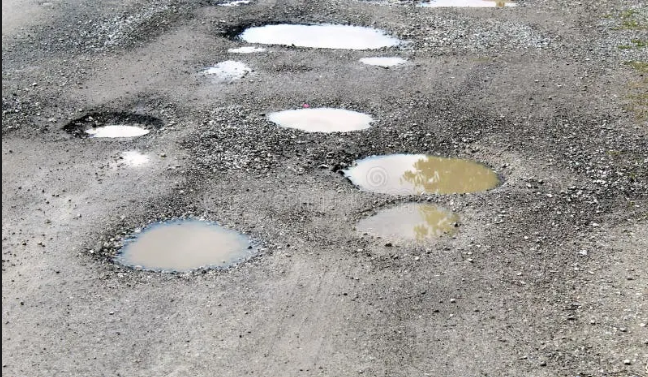

In [ ]:
from IPython.display import Image

Image("red.png")

In [ ]:
results = model.predict(
    source="red.png",
    save=True,
    conf=0.10,
    show_boxes=True,
    show_labels=True,
    retina_masks=True
)


image 1/1 /content/red.png: 384x640 12 patchs, 8.6ms
Speed: 2.6ms preprocess, 8.6ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/segment/predict


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/segment/pothole_seg_training/yolov8_seg/weights/best.pt"
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:

model = YOLO("/content/runs/segment/pothole_seg_training/yolov8_seg/weights/best.pt")
metrics = model.val()
print(metrics)


Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,454 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1652.5±711.9 MB/s, size: 38.7 KB)
val: Scanning /content/Potholes-detection-10/valid/labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 8.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1it/s 1.8s
                   all         19         59      0.205      0.446      0.275      0.182      0.197      0.436       0.25      0.165
               pothole          2          4     0.0858        0.5      0.279      0.235     0.0861        0.5      0.274      0.225
                 patch         17         55      0.324      0.392      0.271       0.13      0.308      0.373      0.226      0.105
Speed: 1.5ms preprocess, 16.9ms infe

In [ ]:

results = model.predict(
    source="red.png",  # image or video path
    save=True,
    conf=0.25
)

print("Inference complete.")



image 1/1 /content/red.png: 384x640 7 patchs, 8.3ms
Speed: 2.3ms preprocess, 8.3ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/segment/predict-2
Inference complete.


In [ ]:
import pandas as pd
import numpy as np

rows = []

for frame_idx, result in enumerate(results):

    n_boxes = len(result.boxes) if result.boxes is not None else 0

    for pothole_id in range(n_boxes):

        cls = int(result.boxes.cls[pothole_id].item())
        conf = float(result.boxes.conf[pothole_id].item())

        # Skip patches if desired
        # if cls == 1:
        #     continue

        if result.masks is not None and pothole_id < len(result.masks.xy):

            mask = result.masks.xy[pothole_id]

            xs = mask[:, 0]
            ys = mask[:, 1]

            width = max(xs) - min(xs)
            height = max(ys) - min(ys)

            approx_diameter = (width + height) / 2

        else:
            # Fallback to bounding box
            x1, y1, x2, y2 = result.boxes.xyxy[pothole_id].cpu().numpy()

            width = x2 - x1
            height = y2 - y1

            approx_diameter = (width + height) / 2

        rows.append({
            "Frame": frame_idx,
            "Pothole_ID": pothole_id,
            "Class": cls,
            "Confidence": conf,
            "Approx_Diameter_pixels": approx_diameter
        })

df = pd.DataFrame(rows)

df.to_csv("pothole_segmentation_results.csv", index=False)

print(df)


   Frame  Pothole_ID  Class  Confidence  Approx_Diameter_pixels
0      0           0      1    0.883639              118.462494
1      0           1      1    0.864518               77.456253
2      0           2      1    0.807182              138.712494
3      0           3      1    0.795215              152.887512
4      0           4      1    0.776706               71.887505
5      0           5      1    0.673964              124.537498
6      0           6      1    0.533178               59.231255


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving road_video.mp4 to road_video.mp4


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/segment/pothole_seg_training/yolov8_seg/weights/best.pt"
)

In [ ]:
results = model.predict(
    source="road_video.mp4",
    save=True,
    conf=0.10,
    iou=0.4,
    show_boxes=True,
    show_labels=True,
    retina_masks=True,
    stream=True
)

In [ ]:
import pandas as pd

rows = []

for frame_idx, result in enumerate(results):

    n_boxes = len(result.boxes) if result.boxes is not None else 0

    for pothole_id in range(n_boxes):

        cls = int(result.boxes.cls[pothole_id].item())
        conf = float(result.boxes.conf[pothole_id].item())

        # Ignore patches if desired
        # if cls == 1:
        #     continue

        if result.masks is not None and pothole_id < len(result.masks.xy):

            mask = result.masks.xy[pothole_id]

            xs = mask[:, 0]
            ys = mask[:, 1]

            width = max(xs) - min(xs)
            height = max(ys) - min(ys)

            diameter = (width + height) / 2

        else:
            x1, y1, x2, y2 = result.boxes.xyxy[pothole_id].cpu().numpy()

            width = x2 - x1
            height = y2 - y1

            diameter = (width + height) / 2

        rows.append({
            "Frame": frame_idx,
            "Pothole_ID": pothole_id,
            "Class": model.names[cls],
            "Confidence": conf,
            "Approx_Diameter_pixels": diameter
        })

df = pd.DataFrame(rows)

df.to_csv(
    "pothole_video_results.csv",
    index=False
)

print(df.head())
print("Saved pothole_video_results.csv")


video 1/1 (frame 1/287) /content/road_video.mp4: 384x640 3 potholes, 10.8ms
video 1/1 (frame 2/287) /content/road_video.mp4: 384x640 1 pothole, 8.0ms
video 1/1 (frame 3/287) /content/road_video.mp4: 384x640 3 potholes, 7.2ms
video 1/1 (frame 4/287) /content/road_video.mp4: 384x640 2 potholes, 7.6ms
video 1/1 (frame 5/287) /content/road_video.mp4: 384x640 2 potholes, 7.2ms
video 1/1 (frame 6/287) /content/road_video.mp4: 384x640 2 potholes, 7.5ms
video 1/1 (frame 7/287) /content/road_video.mp4: 384x640 2 potholes, 1 patch, 7.3ms
video 1/1 (frame 8/287) /content/road_video.mp4: 384x640 2 potholes, 1 patch, 8.9ms
video 1/1 (frame 9/287) /content/road_video.mp4: 384x640 2 potholes, 1 patch, 7.4ms
video 1/1 (frame 10/287) /content/road_video.mp4: 384x640 2 potholes, 1 patch, 7.6ms
video 1/1 (frame 11/287) /content/road_video.mp4: 384x640 2 potholes, 7.4ms
video 1/1 (frame 12/287) /content/road_video.mp4: 384x640 2 potholes, 7.7ms
video 1/1 (frame 13/287) /content/road_video.mp4: 384x640 2 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE = "/content/drive/MyDrive/RHMS"

folders = [
    BASE,
    BASE+"/Locations"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folders created.")

Folders created.


In [ ]:
!cp /content/runs/segment/pothole_seg_training/yolov8_seg/weights/best.pt \
"/content/drive/MyDrive/RHMS/"

In [ ]:
import os

BASE = "/content/drive/MyDrive/RHMS"

location_id = "LOC001"

loc_folder = os.path.join(
    BASE,
    "Locations",
    location_id
)

os.makedirs(loc_folder, exist_ok=True)

print(loc_folder)

/content/drive/MyDrive/RHMS/Locations/LOC001


In [ ]:
import sqlite3

DB_PATH = "/content/drive/MyDrive/RHMS/database.db"

def register_location(location_id, latitude, longitude):

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    INSERT OR IGNORE INTO locations
    (location_id, latitude, longitude)
    VALUES (?, ?, ?)
    """,
    (
        location_id,
        latitude,
        longitude
    ))

    conn.commit()
    conn.close()

In [ ]:
register_location(
    "LOC001",
    32.7266,
    74.8570
)

In [ ]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute("SELECT * FROM locations")
print(cursor.fetchall())

conn.close()

[('LOC001', 32.7266, 74.857)]


In [ ]:
location_id = "LOC001"
latitude = 32.7266
longitude = 74.8570

register_location(
    location_id,
    latitude,
    longitude
)

In [ ]:
def get_severity(avg_diameter , pothole_count):

    score = avg_diameter + 10*pothole_count

    if score < 100:
        return "Low"

    elif score < 250:
        return "Medium"

    else:
        return "High"

In [ ]:
from datetime import datetime

def save_detection(
        location_id,
        pothole_count,
        avg_diameter ,
        severity):

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO detections
    (
        location_id,
        timestamp,
        pothole_count,
        avg_diameter,
        severity
    )
    VALUES(?,?,?,?,?)
    """,
    (
        location_id,
        str(datetime.now()),
        pothole_count,
        avg_diameter,
        severity
    ))

    conn.commit()
    conn.close()

In [ ]:
df

,Frame,Pothole_ID,Class,Confidence,Approx_Diameter_pixels
0,0,0,pothole,0.663095,96.0
1,0,1,pothole,0.122382,80.5
2,0,2,pothole,0.111912,65.0
3,1,0,pothole,0.482355,100.5
4,2,0,pothole,0.374419,94.5
...,...,...,...,...,...
651,284,0,pothole,0.125192,75.5
652,284,1,pothole,0.103948,71.0
653,285,0,pothole,0.165330,70.0
654,285,1,pothole,0.119029,71.0


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1tQvh7F7-cd4qoWb1FNVuLZZqyjF3-uyFmkNQeynfVNI/edit#gid=0


In [ ]:
avg_diameter = (
    df["Approx_Diameter_pixels"]
    .mean()
)

pothole_count = len(df)

In [ ]:
severity = get_severity(
    avg_diameter,
    pothole_count
)

save_detection(
    location_id,
    pothole_count,
    avg_diameter,
    severity
)

In [ ]:
def save_media(
        location_id,
        original_file,
        detected_file,
        pothole_csv):

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO media
    (
        location_id,
        original_file,
        detected_file,
        pothole_csv,
        upload_time
    )
    VALUES(?,?,?,?,datetime('now'))
    """,
    (
        location_id,
        original_file,
        detected_file,
        pothole_csv
    ))

    conn.commit()
    conn.close()

In [ ]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print("LOCATIONS")
cursor.execute("SELECT * FROM locations")
print(cursor.fetchall())

print("\nDETECTIONS")
cursor.execute("SELECT * FROM detections")
print(cursor.fetchall())

print("\nMEDIA")
cursor.execute("SELECT * FROM media")
print(cursor.fetchall())

conn.close()

LOCATIONS
[('LOC001', 32.7266, 74.857)]

DETECTIONS
[(1, 'LOC001', '2026-06-24 10:08:00.824418', 656, b'j\xd7\xd2B', 'High')]

MEDIA
[]


In [ ]:
print(register_location)
print(save_detection)
print(save_media)
print(get_severity)

<function register_location at 0x7b83e1120360>
<function save_detection at 0x7b83dd1df920>
<function save_media at 0x7b83e149a700>
<function get_severity at 0x7b83e1120400>


In [ ]:
def process_image(
        image_path,
        location_id,
        latitude,
        longitude):

    print("Image:", image_path)
    print("Location:", location_id)
    print("Latitude:", latitude)
    print("Longitude:", longitude)

    register_location(
        location_id,
        latitude,
        longitude
    )

    print("Location registered successfully.")

    results = model(image_path)

    rows = []
    for frame_idx, result in enumerate(results):
        n_boxes = len(result.boxes) if result.boxes is not None else 0

        for pothole_id in range(n_boxes):
            cls = int(result.boxes.cls[pothole_id].item())
            conf = float(result.boxes.conf[pothole_id].item())

            if result.masks is not None and pothole_id < len(result.masks.xy):
                mask = result.masks.xy[pothole_id]
                xs = mask[:, 0]
                ys = mask[:, 1]
                width = max(xs) - min(xs)
                height = max(ys) - min(ys)
                approx_diameter = (width + height) / 2
            else:
                x1, y1, x2, y2 = result.boxes.xyxy[pothole_id].cpu().numpy()
                width = x2 - x1
                height = y2 - y1
                approx_diameter = (width + height) / 2

            rows.append({
                "Frame": frame_idx,
                "Pothole_ID": pothole_id,
                "Class": model.names[cls],
                "Confidence": conf,
                "Approx_Diameter_pixels": approx_diameter
            })

    df = pd.DataFrame(rows)
    output_dir = os.path.dirname(DB_PATH)
    csv_name = os.path.join(output_dir, "pothole_video_results.csv")
    df.to_csv(csv_name, index=False)

    avg_diameter = df["Approx_Diameter_pixels"].mean() if len(df) else 0
    pothole_count = len(df)
    severity = get_severity(avg_diameter, pothole_count)

    annotated = results[0].plot() if results else None
    detected_path = os.path.join(output_dir, os.path.splitext(os.path.basename(image_path))[0] + "_detected.jpg")
    if annotated is not None:
        import cv2
        cv2.imwrite(detected_path, annotated)

    save_detection(
        location_id,
        pothole_count,
        avg_diameter,
        severity
    )

    save_media(
        location_id,
        image_path,
        detected_path if annotated is not None else image_path,
        csv_name
    )

    print("Saved detection, media, and pothole CSV.")
    return df


In [ ]:
process_image(
    image_path="road1.jpg",
    location_id="LOC001",
    latitude=32.7266,
    longitude=74.8570
)

Image: road1.jpg
Location: LOC001
Latitude: 32.7266
Longitude: 74.857
Location registered successfully.


In [ ]:
dir()

['BASE',
 'DB_PATH',
 'Image',
 'In',
 'Out',
 'Roboflow',
 'YOLO',
 '_',
 '_21',
 '_45',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_exit_code',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 '_i47',
 '_i48',
 '_i49',
 '_i5',
 '_i50',
 '_i51',
 '_i52',
 '_i53',
 '_i54',
 '_i55',
 '_i56',
 '_i57',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'approx_diameter',
 'avg_diameter',
 'classes',
 'cls',
 'conf',
 'conn',
 'cursor',
 'dataset',
 'dataset_path',
 'datetime',
 'df',
 'diameter',
 'drive',
 'exit',
 'f',
 'file',
 'files',
 'folder',
 'folders',
 'frame_idx

In [ ]:
print(process_image)

<function process_image at 0x7b83e149bc40>


In [ ]:
help(process_image)

Help on function process_image in module __main__:

process_image(image_path, location_id, latitude, longitude)



In [ ]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print("LOCATIONS")
cursor.execute("SELECT * FROM locations")
print(cursor.fetchall())

print("\nDETECTIONS")
cursor.execute("SELECT * FROM detections")
print(cursor.fetchall())

print("\nMEDIA")
cursor.execute("SELECT * FROM media")
print(cursor.fetchall())

conn.close()

LOCATIONS
[('LOC001', 32.7266, 74.857)]

DETECTIONS
[(1, 'LOC001', '2026-06-24 10:08:00.824418', 656, b'j\xd7\xd2B', 'High')]

MEDIA
[]


In [ ]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute("""
DELETE FROM detections
""")

conn.commit()
conn.close()

print("detections table cleared")

detections table cleared
